# Module 1: The Tools-to-Production Translation Gap

**Question:** Among recent top prospects, who had elite physical tools but poor MLB results?

We compute a "tools score" (exit velo, barrel rate, hard-hit rate) and a "results score" (wOBA) for each prospect's first 2 MLB seasons, then identify the biggest gaps. This is the foundation — it establishes *who* is failing and *how much* their tools should predict better outcomes.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="urllib3")

import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from fire_fishman.data.statcast import get_statcast_pitches, get_batting_stats
from fire_fishman.data.prospects import get_prospect_df, get_prospect_ids
from fire_fishman.features.tools_score import compute_tools_for_cohort
from fire_fishman.features.translation import compute_results_score, compute_translation_gap

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 7)

## 1. Load Data

Pull Statcast pitch-level data and FanGraphs season stats. First run will take several minutes per season as it downloads from Baseball Savant.

In [2]:
# Pull data for 2023 and 2024 seasons
pitches_2023 = get_statcast_pitches(2023)
pitches_2024 = get_statcast_pitches(2024)
pitches = pd.concat([pitches_2023, pitches_2024], ignore_index=True)

batting_2023 = get_batting_stats(2023)
batting_2024 = get_batting_stats(2024)

prospects = get_prospect_df()
print(f"Tracking {len(prospects)} prospects")
prospects.head(10)

Tracking 24 prospects


,name,mlbam_id,debut_year,pre_debut_rank,outcome
0,Anthony Volpe,683011,2023,5,disappointing
1,Jasson Dominguez,691176,2023,15,disappointing
2,Ben Rice,700250,2024,50,solid
3,Julio Rodriguez,677594,2022,1,star
4,Bobby Witt Jr.,677951,2022,1,star
5,Gunnar Henderson,683002,2022,2,star
6,Corbin Carroll,682998,2022,3,star
7,Adley Rutschman,668939,2022,1,star
8,Riley Greene,682985,2022,10,star
9,CJ Abrams,682928,2022,8,solid


## 2. Compute Tools Scores

For each prospect, compute physical tool metrics from their batted ball data.

In [3]:
batter_ids = prospects["mlbam_id"].tolist()
tools_df = compute_tools_for_cohort(pitches, batter_ids)
tools_df = tools_df.join(prospects.set_index("mlbam_id")[["name", "outcome"]])

print("Tools scores (sorted by composite):")
tools_df.sort_values("tools_composite_z", ascending=False)[
    ["name", "avg_exit_velo", "barrel_rate", "hard_hit_rate", "tools_composite_z"]
]

Tools scores (sorted by composite):


,name,avg_exit_velo,barrel_rate,hard_hit_rate,tools_composite_z
batter_id,,,,,
683002,Gunnar Henderson,84.723516,0.037625,0.315109,1.288445
677594,Julio Rodriguez,84.691040,0.038484,0.298105,1.227267
677951,Bobby Witt Jr.,84.433547,0.043478,0.281621,1.142339
682829,Elly De La Cruz,83.658890,0.034594,0.266291,0.686049
694192,Jackson Chourio,84.072261,0.029126,0.289875,0.625484
682985,Riley Greene,83.185788,0.036269,0.256107,0.484441
691176,Jasson Dominguez,81.656911,0.032520,0.308943,0.388053
672284,Jarred Kelenic,83.673465,0.028713,0.268317,0.387587
682998,Corbin Carroll,82.892499,0.027698,0.263128,0.295238


## 3. Compute Results Scores

In [4]:
# Use most recent full-season batting stats for each prospect
results_records = []
for _, row in prospects.iterrows():
    # Try 2024 first, fall back to 2023
    res = compute_results_score(batting_2024, row["name"])
    if np.isnan(res.get("woba", np.nan)):
        res = compute_results_score(batting_2023, row["name"])
    res["batter_id"] = row["mlbam_id"]
    results_records.append(res)

results_df = pd.DataFrame(results_records).set_index("batter_id")
results_df.head()

,woba,wrc_plus,ops
batter_id,,,
683011,0.287,87.0,0.657
691176,0.285,86.0,0.617
700250,0.269,74.0,0.613
677594,0.321,116.0,0.734
677951,0.410,169.0,0.977


## 4. The Translation Gap

This is the key plot. X-axis = tools (physical ability), Y-axis = results (production).

Prospects **above** the diagonal are overperforming their tools.  
Prospects **below** the diagonal are underperforming — the translation gap.

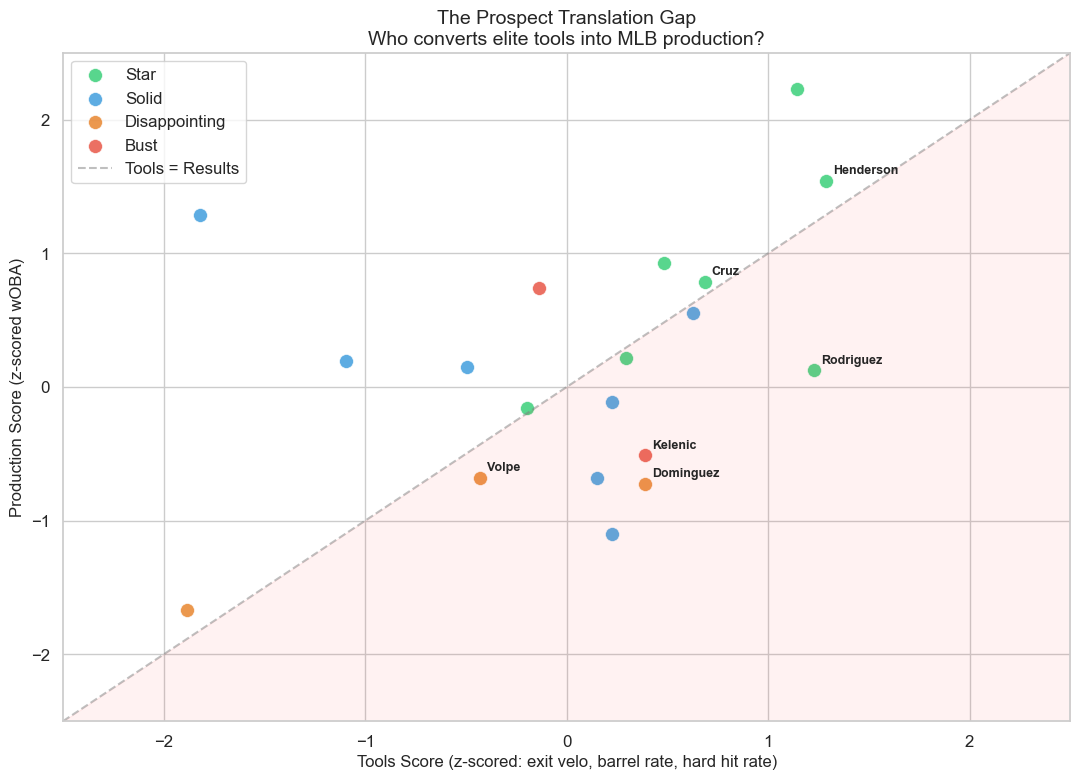

In [5]:
gap_df = compute_translation_gap(tools_df, results_df)

fig, ax = plt.subplots(figsize=(11, 8))

# Color by outcome
colors = {"star": "#2ecc71", "solid": "#3498db", "disappointing": "#e67e22", "bust": "#e74c3c"}
for outcome, color in colors.items():
    mask = gap_df["outcome"] == outcome
    ax.scatter(
        gap_df.loc[mask, "tools_composite_z"],
        gap_df.loc[mask, "woba_z"],
        c=color, label=outcome.title(), s=100, alpha=0.8, edgecolors="white", linewidth=0.5,
    )

# Label key prospects
for idx, row in gap_df.iterrows():
    if row["name"] in ["Anthony Volpe", "Jasson Dominguez", "Julio Rodriguez",
                        "Jarred Kelenic", "Gunnar Henderson", "Elly De La Cruz",
                        "Spencer Torkelson", "Jordan Walker"]:
        ax.annotate(
            row["name"].split()[-1],
            (row["tools_composite_z"], row["woba_z"]),
            fontsize=9, fontweight="bold",
            xytext=(5, 5), textcoords="offset points",
        )

# Diagonal line (tools = results)
lims = [-2.5, 2.5]
ax.plot(lims, lims, "--", color="gray", alpha=0.5, label="Tools = Results")
ax.fill_between(lims, lims, [-3, -3], alpha=0.05, color="red")  # underperforming zone

ax.set_xlabel("Tools Score (z-scored: exit velo, barrel rate, hard hit rate)", fontsize=12)
ax.set_ylabel("Production Score (z-scored wOBA)", fontsize=12)
ax.set_title("The Prospect Translation Gap\nWho converts elite tools into MLB production?", fontsize=14)
ax.legend(loc="upper left")
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.savefig("../outputs/figures/translation_gap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Translation Gap Leaderboard

In [6]:
print("Biggest UNDERPERFORMERS (tools >> results):")
gap_df.sort_values("translation_gap", ascending=False)[
    ["name", "tools_composite_z", "woba_z", "translation_gap", "woba"]
].head(10)

Biggest UNDERPERFORMERS (tools >> results):


,name,tools_composite_z,woba_z,translation_gap,woba
batter_id,,,,,
700250,Ben Rice,0.226168,-1.103623,1.329792,0.269
691176,Jasson Dominguez,0.388053,-0.725361,1.113414,0.285
677594,Julio Rodriguez,1.227267,0.125729,1.101538,0.321
672284,Jarred Kelenic,0.387587,-0.512588,0.900175,0.294
666134,Nolan Jones,0.148838,-0.678078,0.826916,0.287
673962,Josh Jung,0.226686,-0.110685,0.337371,0.311
683011,Anthony Volpe,-0.429737,-0.678078,0.248341,0.287
682998,Corbin Carroll,0.295238,0.220295,0.074944,0.325
694192,Jackson Chourio,0.625484,0.551274,0.074210,0.339


In [7]:
print("Biggest OVERPERFORMERS (results >> tools):")
gap_df.sort_values("translation_gap", ascending=True)[
    ["name", "tools_composite_z", "woba_z", "translation_gap", "woba"]
].head(10)

Biggest OVERPERFORMERS (results >> tools):


,name,tools_composite_z,woba_z,translation_gap,woba
batter_id,,,,,
680757,Matt McLain,-1.821038,1.284157,-3.105195,0.370
678545,Ezequiel Tovar,-1.095517,0.196653,-1.292170,0.324
677951,Bobby Witt Jr.,1.142339,2.229813,-1.087474,0.410
663698,Joey Bart,-0.135602,0.740405,-0.876007,0.347
682928,CJ Abrams,-0.495045,0.149371,-0.644416,0.322
682985,Riley Greene,0.484441,0.929537,-0.445096,0.355
683002,Gunnar Henderson,1.288445,1.544213,-0.255767,0.381
663611,Nick Madrigal,-1.883000,-1.671016,-0.211983,0.245
682829,Elly De La Cruz,0.686049,0.787688,-0.101639,0.349


## Takeaways

This establishes the landscape. In Notebook 02, we'll dive into pitch-level Statcast data to diagnose *why* the underperformers are failing — chase rates, whiff rates by pitch type, velocity vulnerability, and count-specific breakdowns.